<a href="https://colab.research.google.com/github/bingjunw/ust-deep-learning-2026/blob/main/Project_Test3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

dataset_path = kagglehub.dataset_download("ikarus777/best-artworks-of-all-time")
train_dir = os.path.join(dataset_path, "images", "images")

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.1)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='input',
    subset='training'
)

100%|██████████| 2.29G/2.29G [00:30<00:00, 81.4MB/s]

Extracting files...


Found 7921 images belonging to 51 classes.


In [3]:
def build_gray_autoencoder():
    input_img = layers.Input(shape=(128, 128, 1))

    # Encoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    encoded = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name="encoder_output")(x)

    # Decoder
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    auto = models.Model(input_img, decoded)
    auto.compile(optimizer='adam', loss='mse')
    return auto

gray_ae = build_gray_autoencoder()
print("开始灰度特征强化训练...")
gray_ae.fit(train_generator, epochs=25, steps_per_epoch=train_generator.samples // BATCH_SIZE)

开始灰度特征强化训练...
Epoch 1/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 393s 2s/step - loss: 0.0168
Epoch 2/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 50us/step - loss: 0.0088
Epoch 3/25


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


247/247 ━━━━━━━━━━━━━━━━━━━━ 428s 2s/step - loss: 0.0103
Epoch 4/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 48us/step - loss: 0.0095
Epoch 5/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - loss: 0.0094
Epoch 6/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 64us/step - loss: 0.0086
Epoch 7/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - loss: 0.0090
Epoch 8/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 52us/step - loss: 0.0100
Epoch 9/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - loss: 0.0086
Epoch 10/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 49us/step - loss: 0.0091
Epoch 11/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 368s 1s/step - loss: 0.0084
Epoch 12/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 71us/step - loss: 0.0077
Epoch 13/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - loss: 0.0082
Epoch 14/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 73us/step - loss: 0.0067
Epoch 15/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 393s 2s/step - loss: 0.0081
Epoch 16/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 70us/step - loss: 0.0057
Epoch 17/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/ste

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step


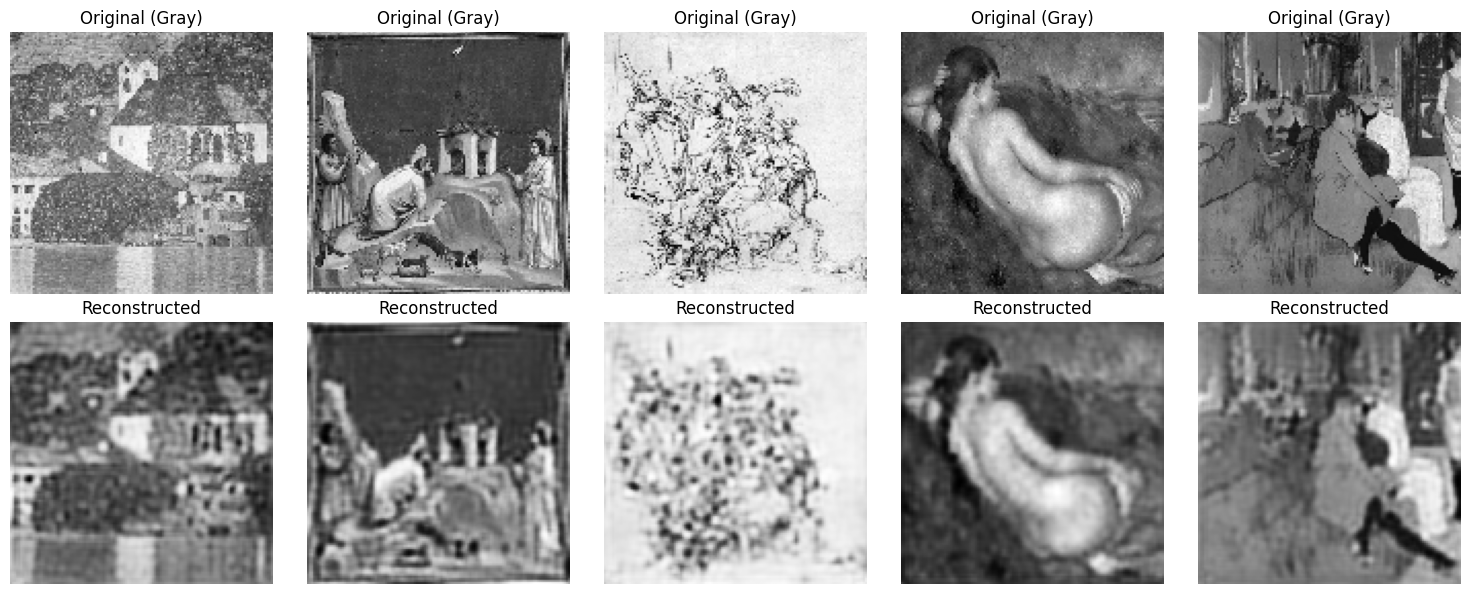

In [4]:
batch_x, _ = next(train_generator)
reconstructed_imgs = gray_ae.predict(batch_x)

n = 5
plt.figure(figsize=(15, 6))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(batch_x[i].reshape(128, 128), cmap='gray')
    plt.title("Original (Gray)")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_imgs[i].reshape(128, 128), cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

Found 8774 images belonging to 51 classes.


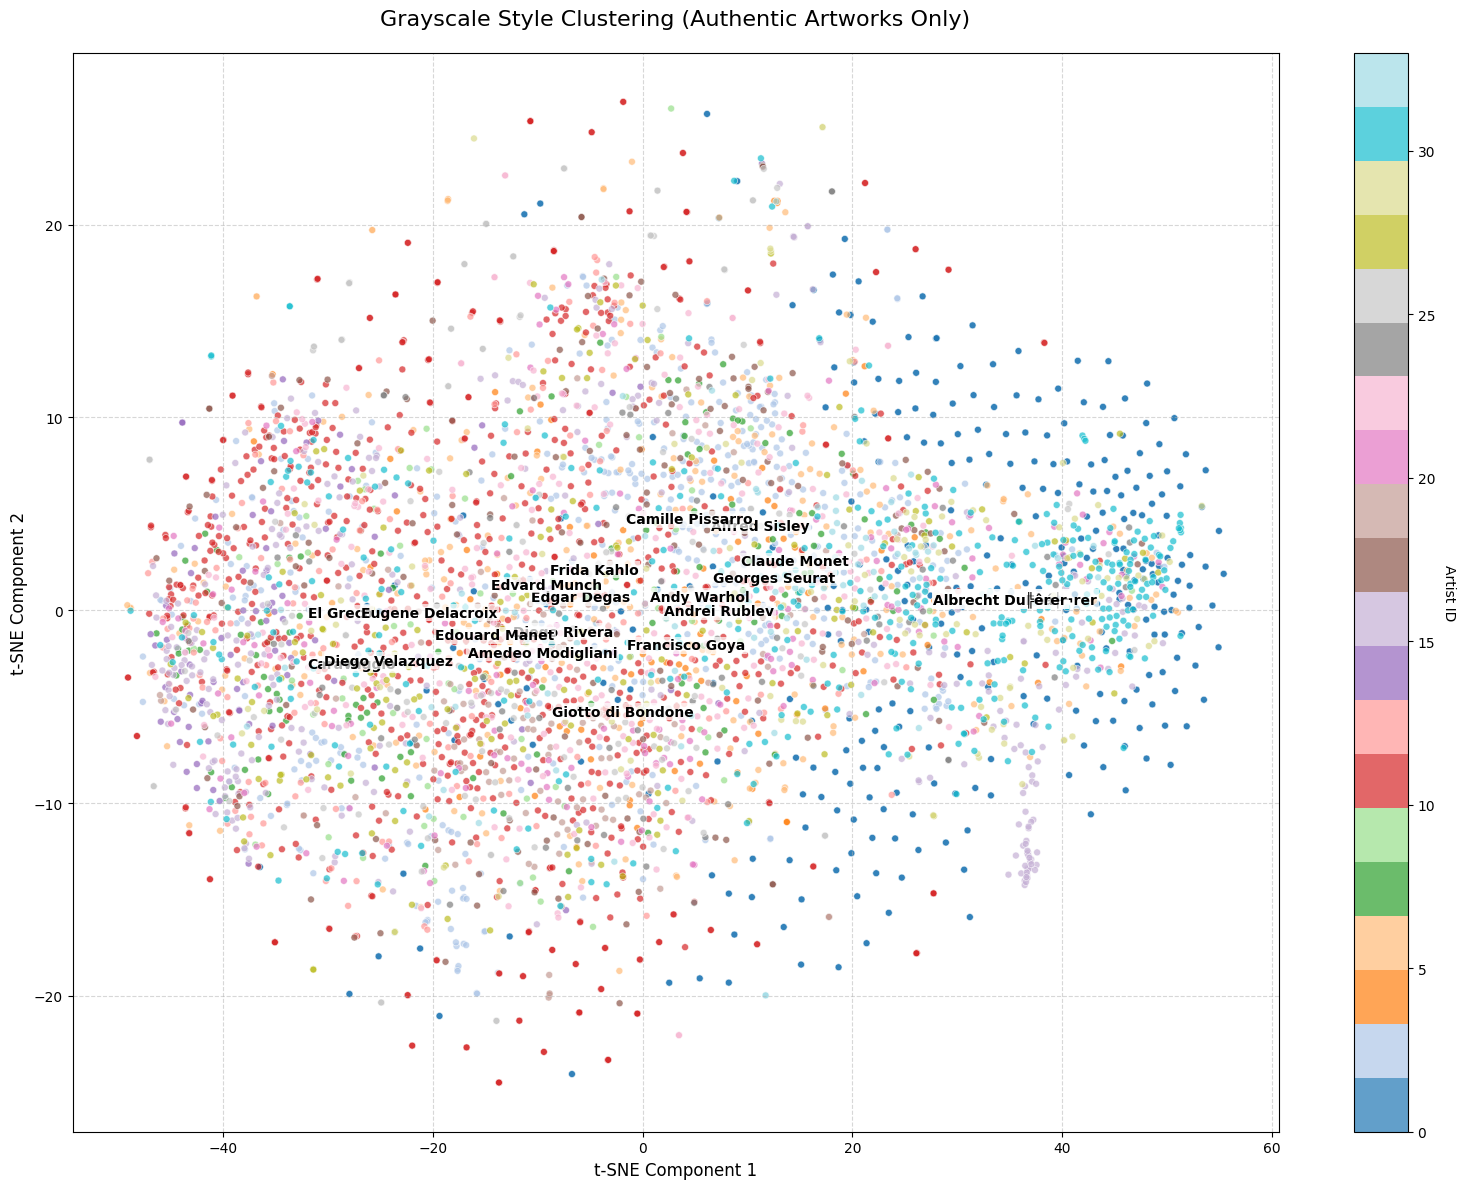

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.manifold import TSNE
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tsne_data_path = os.path.join(dataset_path, "images", "images")
encoder_gray = Model(inputs=gray_ae.input, outputs=gray_ae.get_layer("encoder_output").output)

datagen_tsne = ImageDataGenerator(rescale=1./255)
tsne_generator = datagen_tsne.flow_from_directory(
    tsne_data_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='sparse',
    shuffle=False
)

all_features = []
all_labels = []
num_batches = min(len(tsne_generator), 150)

for i in range(num_batches):
    batch_x, batch_y = next(tsne_generator)
    feat = encoder_gray.predict(batch_x, verbose=0)
    feat_flattened = feat.reshape(feat.shape[0], -1)
    all_features.append(feat_flattened)
    all_labels.append(batch_y)

X_features = np.vstack(all_features)
y_labels = np.concatenate(all_labels)

tsne = TSNE(n_components=2, perplexity=45, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_features)

label_map = {v: k for k, v in tsne_generator.class_indices.items()}
unique_labels = np.unique(y_labels)

plt.figure(figsize=(16, 12))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_labels, cmap='tab20', alpha=0.7, s=25, edgecolors='white', linewidth=0.5)

cbar = plt.colorbar(scatter)
cbar.set_label('Artist ID', rotation=270, labelpad=15)

plt.title("Grayscale Style Clustering (Authentic Artworks Only)", fontsize=16, pad=20)
plt.xlabel("t-SNE Component 1", fontsize=12)
plt.ylabel("t-SNE Component 2", fontsize=12)

for label in unique_labels:
    if label >= 20:
        break
    indices = np.where(y_labels == label)[0]
    if len(indices) > 0:
        centroid_x = np.mean(X_tsne[indices, 0])
        centroid_y = np.mean(X_tsne[indices, 1])
        display_name = label_map[label].replace('_', ' ')
        plt.text(centroid_x, centroid_y, display_name, fontsize=10, fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

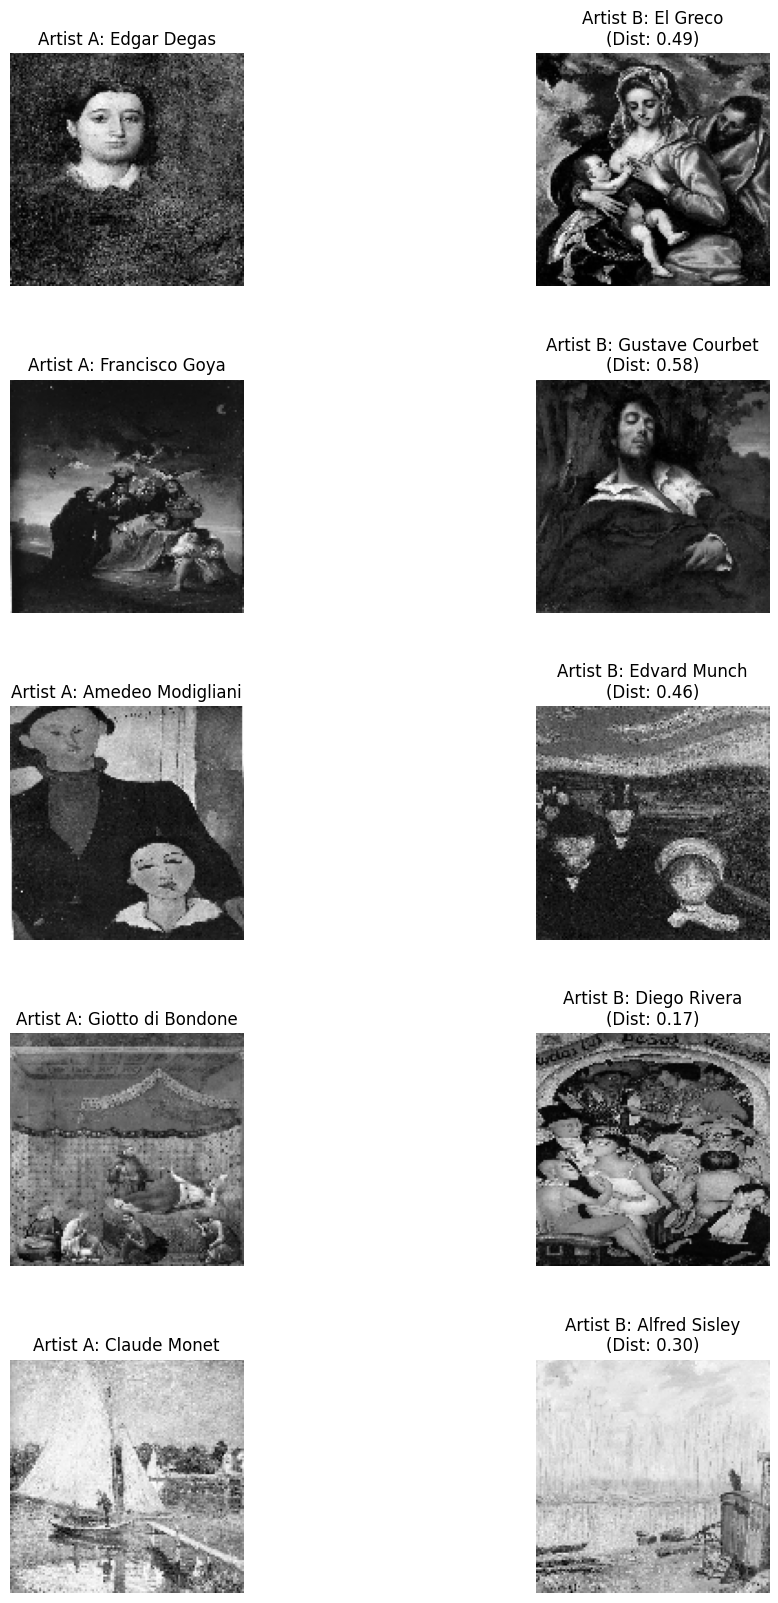

In [25]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

def verify_grayscale_features(X_tsne, y_labels, generator, n_pairs=5):
    nn = NearestNeighbors(n_neighbors=100)
    nn.fit(X_tsne)

    pairs_found = 0
    used_indices = set()
    label_map = {v: k for k, v in generator.class_indices.items()}

    fig, axes = plt.subplots(n_pairs, 2, figsize=(12, 4 * n_pairs))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)

    indices_to_check = np.random.choice(len(X_tsne), len(X_tsne), replace=False)

    for i in indices_to_check:
        if pairs_found >= n_pairs: break
        if i in used_indices: continue

        distances, neighbor_indices = nn.kneighbors([X_tsne[i]])

        target_neighbor = None
        for neighbor_idx in neighbor_indices[0][1:]:
            if y_labels[i] != y_labels[neighbor_idx]:
                target_neighbor = neighbor_idx
                break

        if target_neighbor is not None:
            img1 = generator[i // BATCH_SIZE][0][i % BATCH_SIZE]
            img2 = generator[target_neighbor // BATCH_SIZE][0][target_neighbor % BATCH_SIZE]

            name1 = label_map[y_labels[i]].replace('_', ' ')
            name2 = label_map[y_labels[target_neighbor]].replace('_', ' ')
            dist_val = np.linalg.norm(X_tsne[i] - X_tsne[target_neighbor])

            axes[pairs_found, 0].imshow(img1.reshape(128, 128), cmap='gray')
            axes[pairs_found, 0].set_title(f"Artist A: {name1}")
            axes[pairs_found, 0].axis('off')

            axes[pairs_found, 1].imshow(img2.reshape(128, 128), cmap='gray')
            axes[pairs_found, 1].set_title(f"Artist B: {name2}\n(Dist: {dist_val:.2f})")
            axes[pairs_found, 1].axis('off')

            used_indices.update([i, target_neighbor])
            pairs_found += 1

    plt.show()

verify_grayscale_features(X_tsne, y_labels, tsne_generator)

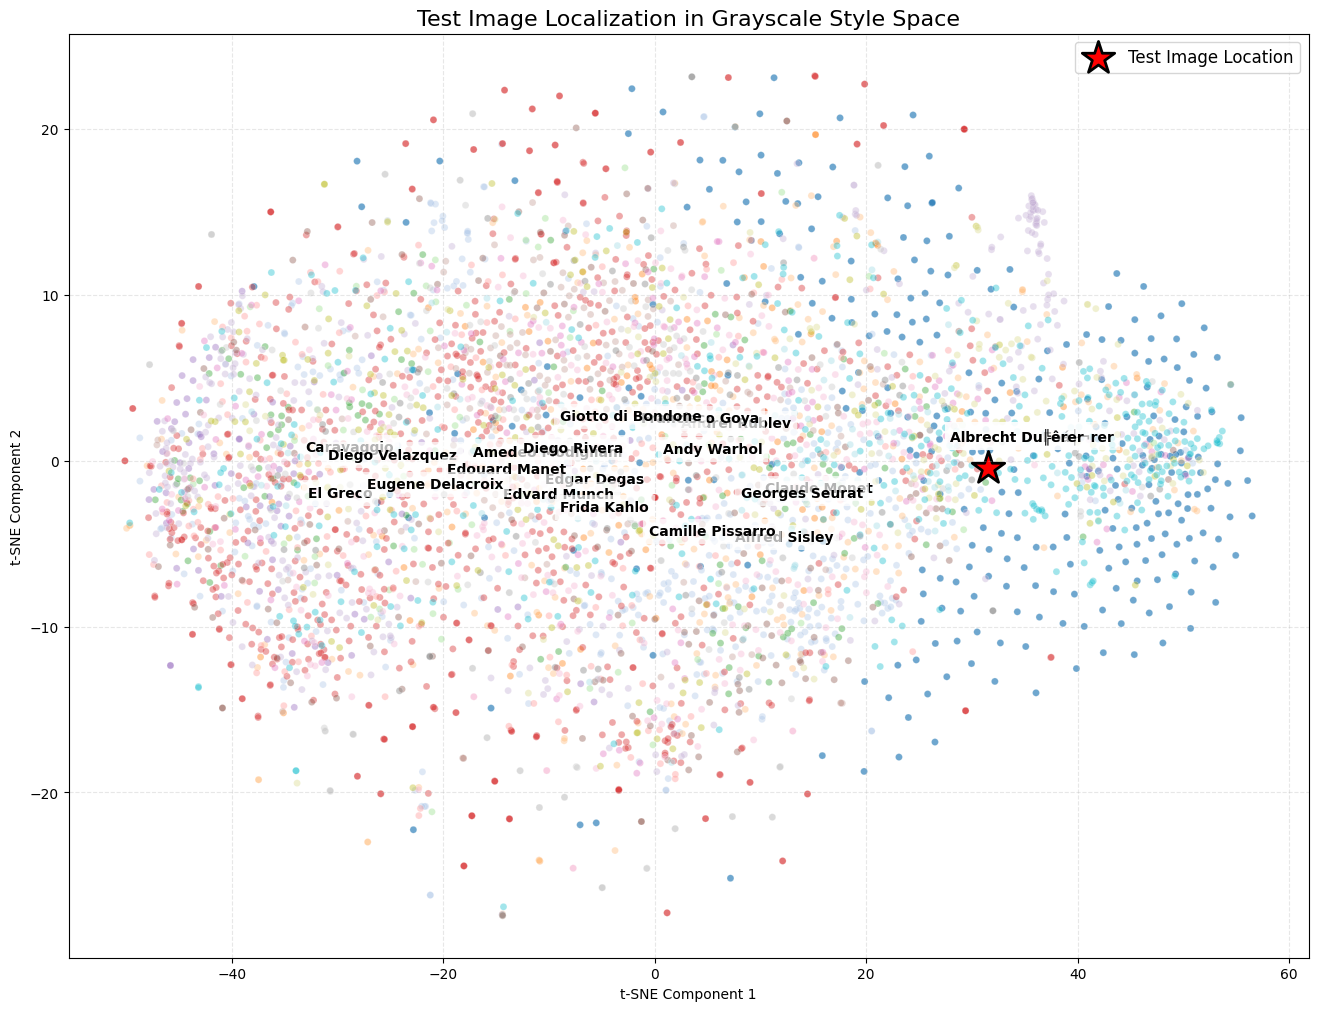

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from tensorflow.keras.preprocessing import image

img_path = 'test.png'
test_img = image.load_img(img_path, target_size=IMG_SIZE, color_mode='grayscale')
test_arr = image.img_to_array(test_img) / 255.0
test_arr = np.expand_dims(test_arr, axis=0)

test_feat = encoder_gray.predict(test_arr, verbose=0).reshape(1, -1)

X_combined = np.vstack([X_features, test_feat])
tsne_final = TSNE(n_components=2, perplexity=45, random_state=42, init='pca', learning_rate='auto')
X_tsne_combined = tsne_final.fit_transform(X_combined)

X_tsne_background = X_tsne_combined[:-1]
test_point = X_tsne_combined[-1]

plt.figure(figsize=(16, 12))
plt.scatter(X_tsne_background[:, 0], X_tsne_background[:, 1], c=y_labels, cmap='tab20', alpha=0.4, s=25, edgecolors='white', linewidth=0.3)
plt.scatter(test_point[0], test_point[1], c='red', marker='*', s=600, label='Test Image Location', edgecolors='black', linewidth=2)

for label in np.unique(y_labels):
    if label >= 20: break
    indices = np.where(y_labels == label)[0]
    if len(indices) > 0:
        cx, cy = np.mean(X_tsne_background[indices, 0]), np.mean(X_tsne_background[indices, 1])
        plt.text(cx, cy, label_map[label].replace('_', ' '), fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.title("Test Image Localization in Grayscale Style Space", fontsize=16)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()